# S&P 500 Clustering Pipeline
Single notebook with feature-case tuning, **k selection**, temporal stability evaluation (train → validation → test), and **mean + std aggregation** per stock.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 2. Load Data

In [2]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"
unseen_path = "data/sp500_unseen.csv"

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).copy()

# Split into train (3y), validation (1y), unseen (most recent 1y)
unseen_end = df['Date'].max().normalize()
unseen_start = unseen_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
val_end = unseen_start - pd.Timedelta(days=1)
val_start = val_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
train_end = val_start - pd.Timedelta(days=1)
data_start = train_end - pd.DateOffset(years=3) + pd.Timedelta(days=1)

train_df = df[(df['Date'] >= data_start) & (df['Date'] <= train_end)].copy()
val_df = df[(df['Date'] >= val_start) & (df['Date'] <= val_end)].copy()
unseen_df = df[(df['Date'] >= unseen_start) & (df['Date'] <= unseen_end)].copy()

# Keep only stocks that appear in all 3 buckets
common_symbols = (
    set(train_df['Symbol'])
    .intersection(val_df['Symbol'])
    .intersection(unseen_df['Symbol'])
)
train_df = train_df[train_df['Symbol'].isin(common_symbols)].copy()
val_df = val_df[val_df['Symbol'].isin(common_symbols)].copy()
unseen_df = unseen_df[unseen_df['Symbol'].isin(common_symbols)].copy()

unseen_df.to_csv(unseen_path, index=False)

# Keep only training + validation in the notebook dataset
notebook_data = pd.concat([train_df, val_df], ignore_index=True)
notebook_data = notebook_data.sort_values(['Symbol', 'Date']).copy()
df = notebook_data.copy()

print("Train window:", train_df['Date'].min().date(), "to", train_df['Date'].max().date())
print("Validation window:", val_df['Date'].min().date(), "to", val_df['Date'].max().date())
print("Unseen window:", unseen_df['Date'].min().date(), "to", unseen_df['Date'].max().date())
print("Stocks (train/val/unseen):", train_df['Symbol'].nunique(), val_df['Symbol'].nunique(), unseen_df['Symbol'].nunique())
print("Notebook rows:", len(df))
print("Unseen rows:", len(unseen_df))
print("Unseen CSV saved to:", unseen_path)
df.head(2)


Train window: 2021-03-22 to 2024-03-20
Validation window: 2024-03-21 to 2025-03-20
Unseen window: 2025-03-21 to 2026-03-20
Stocks (train/val/unseen): 499 499 499
Notebook rows: 499550
Unseen rows: 125248
Unseen CSV saved to: data/sp500_unseen.csv


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
0,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
1,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005


## 3. Feature Engineering


In [3]:
import numpy as np
import pandas as pd

def create_features(df, include_today=True, use_log_volatility=False):
    """
    Create rolling-window features for clustering.

    Features:
      - log_return_1D
      - volume_change_1D
      - log_return_5D, log_return_21D       : rolling sum of daily log returns
      - volatility_5D, volatility_21D       : rolling std of daily log returns
      - volume_change_5D, volume_change_21D : rolling sum of daily log volume changes

    Options:
      include_today:
        True  -> feature windows end at t
        False -> feature windows are shifted back by 1 day to end at t-1

      use_log_volatility:
        False -> keep rolling std as volatility_* columns
        True  -> store log of rolling std as log_volatility_* columns
    """
    d = df.copy()
    d = d.sort_values(["Symbol", "Date"]).reset_index(drop=True)

    price_col = "Adj Close" if "Adj Close" in d.columns else "Close"

    # Base logged series
    d["log_price"] = np.log(d[price_col])
    d["log_volume"] = np.log(d["Volume"].clip(lower=1))

    g = d.groupby("Symbol", group_keys=False)

    # Daily base series
    d["log_return_1D"] = g["log_price"].diff(1)
    d["volatility_1D"] = d["log_return_1D"].abs()
    d["volume_change_1D"] = g["log_volume"].diff(1)

    windows = [5, 21]

    for w in windows:
        # Rolling cumulative return
        ret = (
            g["log_return_1D"]
            .rolling(w)
            .sum()
            .reset_index(level=0, drop=True)
        )

        # Rolling realized volatility
        vol = (
            g["log_return_1D"]
            .rolling(w)
            .std()
            .reset_index(level=0, drop=True)
        )

        # Rolling cumulative log-volume change
        vol_chg = (
            g["volume_change_1D"]
            .rolling(w)
            .sum()
            .reset_index(level=0, drop=True)
        )

        if not include_today:
            ret = ret.groupby(d["Symbol"]).shift(1)
            vol = vol.groupby(d["Symbol"]).shift(1)
            vol_chg = vol_chg.groupby(d["Symbol"]).shift(1)

        d[f"log_return_{w}D"] = ret
        d[f"volume_change_{w}D"] = vol_chg

        if use_log_volatility:
            eps = 1e-12
            d[f"log_volatility_{w}D"] = np.log(vol.clip(lower=eps))
        else:
            d[f"volatility_{w}D"] = vol

    return d

In [4]:
# Apply feature engineering to notebook data (train + validation only)
full_feat = create_features(df)
full_feat.head(2)
# full_feat.to_csv("data/feature_engineered_data.csv", index=False)

,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,...,log_volume,log_return_1D,volatility_1D,volume_change_1D,log_return_5D,volume_change_5D,volatility_5D,log_return_21D,volume_change_21D,volatility_21D
0,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005,...,14.388127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005,...,14.106911,-0.013274,0.013274,-0.281216,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Training & Validation Split (3y / 1y)


In [5]:
train = full_feat[(full_feat['Date'] >= data_start) & (full_feat['Date'] <= train_end)].copy()
val   = full_feat[(full_feat['Date'] >= val_start) & (full_feat['Date'] <= val_end)].copy()

print('Train window:', data_start.date(), 'to', train_end.date())
print('Validation window:', val_start.date(), 'to', val_end.date())
print('Train rows:', len(train))
print('Validation rows:', len(val))

Train window: 2021-03-21 to 2024-03-20
Validation window: 2024-03-21 to 2025-03-20
Train rows: 374800
Validation rows: 124750


## 5. EDA

Rows used: 489,071
Stocks used: 499

Volatility summary (%):


,count,mean_%,p50_%,p95_%,p99_%,max
volatility_1D,489071.0,1.3795,0.9745,3.9630,6.9431,0.7580
volatility_5D,489071.0,1.6796,1.3970,3.7255,5.9311,0.3769
volatility_21D,489071.0,1.8130,1.5933,3.4829,5.1711,0.1805



Share above 2% threshold:


,vol_col,threshold,pct_above_threshold,n_above_threshold,n_total
0,volatility_1D,0.02,21.4889,105096,489071
1,volatility_5D,0.02,26.8141,131140,489071
2,volatility_21D,0.02,29.9306,146382,489071



Stock-level % days above 3% threshold (volatility_1D):


count    499.0000
mean      21.4784
std       10.6559
min        4.3699
10%       10.3455
25%       13.4654
50%       19.1057
75%       27.5407
90%       35.3659
95%       42.3984
max       66.6322
Name: volatility_1D, dtype: float64

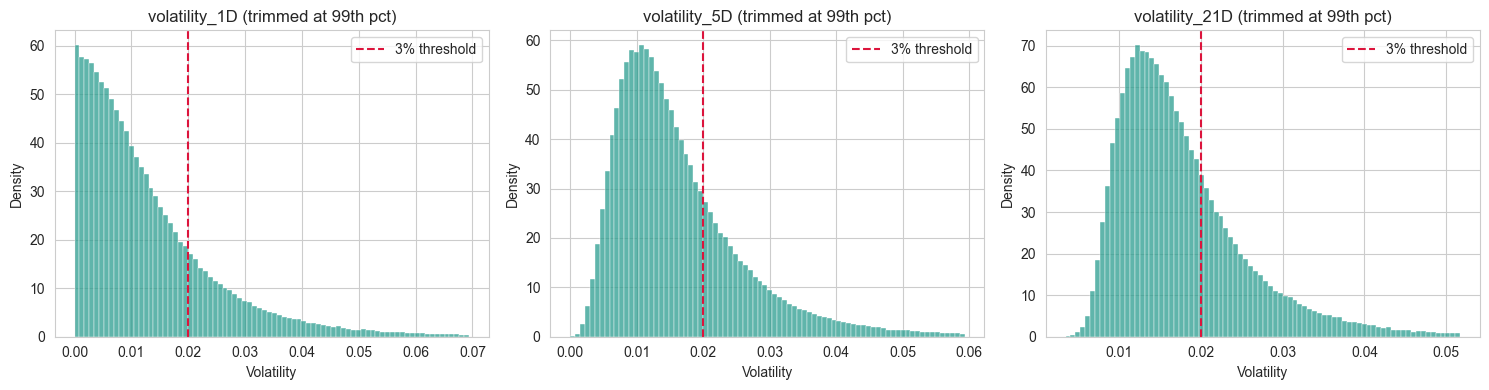

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1) Load feature table
if "full_feat" in globals():
    eda = full_feat.copy()
elif Path("feature_engineered_data.csv").exists():
    eda = pd.read_csv("feature_engineered_data.csv")
else:
    raise ValueError("No feature table found. Run feature engineering first.")

if "Date" in eda.columns:
    eda["Date"] = pd.to_datetime(eda["Date"], errors="coerce")

# If needed, reconstruct 1D volatility from returns
if "volatility_1D" not in eda.columns and "log_return_1D" in eda.columns:
    eda["volatility_1D"] = eda["log_return_1D"].abs()

# 2) Find volatility horizons
vol_cols = [c for c in ["volatility_1D", "volatility_5D", "volatility_21D"] if c in eda.columns]
if not vol_cols:
    vol_cols = sorted([c for c in eda.columns if c.startswith("volatility_") and c.endswith("D")])

if not vol_cols:
    raise ValueError("No volatility columns found.")

eda = eda.dropna(subset=vol_cols).copy()

print(f"Rows used: {len(eda):,}")
print(f"Stocks used: {eda['Symbol'].nunique():,}" if "Symbol" in eda.columns else "No Symbol column found")

# 3) Distribution summary
summary = eda[vol_cols].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
summary["mean_%"] = summary["mean"] * 100
summary["p50_%"] = summary["50%"] * 100
summary["p95_%"] = summary["95%"] * 100
summary["p99_%"] = summary["99%"] * 100

print("\nVolatility summary (%):")
display(summary[["count", "mean_%", "p50_%", "p95_%", "p99_%", "max"]].round(4))

# 4) Label frequency check (rare event check)
threshold = 0.02  # 3%
freq = pd.DataFrame({
    "vol_col": vol_cols,
    "threshold": threshold,
    "pct_above_threshold": [(eda[c] > threshold).mean() * 100 for c in vol_cols],
    "n_above_threshold": [(eda[c] > threshold).sum() for c in vol_cols],
    "n_total": [len(eda)] * len(vol_cols)
})
print(f"\nShare above {threshold:.0%} threshold:")
display(freq.round(4))

# Extra: stock-level rarity for 1D (if available)
if "volatility_1D" in eda.columns and "Symbol" in eda.columns:
    stock_rate = eda.groupby("Symbol")["volatility_1D"].apply(lambda s: (s > threshold).mean() * 100)
    print("\nStock-level % days above 3% threshold (volatility_1D):")
    display(stock_rate.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(4))

# 5) Plot pooled distributions (trim to 99th percentile for readability)
sns.set_style("whitegrid")
n = len(vol_cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)

for i, col in enumerate(vol_cols):
    ax = axes[0, i]
    cap = eda[col].quantile(0.99)
    x = eda.loc[eda[col] <= cap, col]

    sns.histplot(x, bins=80, stat="density", ax=ax, color="#2a9d8f")
    ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.5, label="3% threshold")
    ax.set_title(f"{col} (trimmed at 99th pct)")
    ax.set_xlabel("Volatility")
    ax.legend()

plt.tight_layout()
plt.show()


In [7]:
threshold = 0.02
y = (eda["volatility_1D"] > threshold).astype(int)

print("Threshold:", f"{threshold:.0%}")
print("Pct above threshold:", round(y.mean() * 100, 2), "%")
print("Counts:")
print(y.value_counts().rename(index={0: "<=2%", 1: ">2%"}))


Threshold: 2%
Pct above threshold: 21.49 %
Counts:
volatility_1D
<=2%    383975
>2%     105096
Name: count, dtype: int64


## Forecasting

### 1. Setup

In [8]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score, precision_recall_fscore_support

THRESHOLD = 0.02   # 2%
N_LAGS = 21        # use past 21 days
RANDOM_STATE = 42


In [9]:
# Use full_feat if already created; otherwise create from df (train+validation data)
if "full_feat" in globals():
    feat = full_feat.copy()
else:
    feat = create_features(df, include_today=True, use_log_volatility=False).copy()

feat["Date"] = pd.to_datetime(feat["Date"])

# Safety: reconstruct 1D vol if missing
if "volatility_1D" not in feat.columns and "log_return_1D" in feat.columns:
    feat["volatility_1D"] = feat["log_return_1D"].abs()

print("Feature rows:", len(feat))
print("Stocks:", feat["Symbol"].nunique())
print("Date window:", feat["Date"].min().date(), "to", feat["Date"].max().date())


Feature rows: 499550
Stocks: 499
Date window: 2021-03-22 to 2025-03-20


In [10]:
base_feats = [
    "log_return_1D", "volatility_1D", "volume_change_1D",
    "log_return_5D", "volatility_5D", "volume_change_5D",
    "log_return_21D", "volatility_21D", "volume_change_21D"
]

missing = [c for c in base_feats if c not in feat.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

model_df = feat.sort_values(["Symbol", "Date"]).copy()
g = model_df.groupby("Symbol", group_keys=False)

# target at t+1
model_df["target_vol_1D_t1"] = g["volatility_1D"].shift(-1)
model_df["target_date"] = g["Date"].shift(-1)

model_df = model_df.dropna(subset=base_feats + ["target_vol_1D_t1", "target_date"]).copy()

print("Model rows (before lags):", len(model_df))
print("Target mean:", round(model_df["target_vol_1D_t1"].mean(), 5))
print("Target p95:", round(model_df["target_vol_1D_t1"].quantile(0.95), 5))

# Model rows are less than feature rows due to NA dropping because of the rolling.
print("Modeling Date window (feature row date):",
      model_df["Date"].min().date(), "to", model_df["Date"].max().date())

print("Modeling Target window (t+1 date):",
      model_df["target_date"].min().date(), "to", model_df["target_date"].max().date())

print("Rows in model_df:", len(model_df))
print("Stocks in model_df:", model_df["Symbol"].nunique())



Model rows (before lags): 488572
Target mean: 0.01379
Target p95: 0.03963
Modeling Date window (feature row date): 2021-04-21 to 2025-03-19
Modeling Target window (t+1 date): 2021-04-22 to 2025-03-20
Rows in model_df: 488572
Stocks in model_df: 499


In [11]:
# Create 21-day historical inputs (NNAR-style lags)

def add_lags_by_symbol(df_in, cols, n_lags=21):
    out = df_in.copy()
    g = out.groupby("Symbol", group_keys=False)
    lag_cols = []
    
    for col in cols:
        for lag in range(1, n_lags + 1):
            name = f"{col}_lag{lag}"
            out[name] = g[col].shift(lag)
            lag_cols.append(name)
    return out, lag_cols

lag_df, lag_cols = add_lags_by_symbol(model_df, base_feats, n_lags=N_LAGS)
lag_df = lag_df.dropna(subset=lag_cols + ["target_vol_1D_t1"]).copy()

print("Rows after lagging:", len(lag_df))
print("Number of input columns:", len(lag_cols))  # should be 9*21 = 189
print("Example lag columns:", lag_cols[:6])


/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_60068/2431063917.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = g[col].shift(lag)
/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_60068/2431063917.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = g[col].shift(lag)
/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_60068/2431063917.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor 

Rows after lagging: 478093
Number of input columns: 189
Example lag columns: ['log_return_1D_lag1', 'log_return_1D_lag2', 'log_return_1D_lag3', 'log_return_1D_lag4', 'log_return_1D_lag5', 'log_return_1D_lag6']


In [12]:
# Uses your existing split boundaries from notebook:
# data_start, train_end, val_start, val_end

train_mask = (lag_df["target_date"] >= data_start) & (lag_df["target_date"] <= train_end)
val_mask   = (lag_df["target_date"] >= val_start) & (lag_df["target_date"] <= val_end)

train_set = lag_df.loc[train_mask].copy()
val_set   = lag_df.loc[val_mask].copy()

X_train = train_set[lag_cols].values
X_val   = val_set[lag_cols].values
y_train = train_set["target_vol_1D_t1"].values
y_val   = val_set["target_vol_1D_t1"].values

y_train_bin = (y_train > THRESHOLD).astype(int)
y_val_bin   = (y_val > THRESHOLD).astype(int)

print("Train target window:", train_set["target_date"].min().date(), "to", train_set["target_date"].max().date())
print("Val target window:", val_set["target_date"].min().date(), "to", val_set["target_date"].max().date())
print("Train rows:", len(train_set), "Val rows:", len(val_set))
print(f"Train % above {THRESHOLD:.0%}:", round(y_train_bin.mean() * 100, 2), "%")
print(f"Val % above {THRESHOLD:.0%}:", round(y_val_bin.mean() * 100, 2), "%")


Train target window: 2021-05-21 to 2024-03-20
Val target window: 2024-03-21 to 2025-03-20
Train rows: 353343 Val rows: 124750
Train % above 2%: 22.65 %
Val % above 2%: 18.21 %


In [13]:
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train)
X_val_reg   = scaler_reg.transform(X_val)

nnar_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    random_state=RANDOM_STATE
)

nnar_reg.fit(X_train_reg, y_train)

pred_train_vol = nnar_reg.predict(X_train_reg)
pred_val_vol   = nnar_reg.predict(X_val_reg)

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train_vol))
rmse_val   = np.sqrt(mean_squared_error(y_val, pred_val_vol))
mae_train  = mean_absolute_error(y_train, pred_train_vol)
mae_val    = mean_absolute_error(y_val, pred_val_vol)

# naive baseline: yesterday's 1D vol (lag1)
naive_val = val_set["volatility_1D_lag1"].values
naive_rmse_val = np.sqrt(mean_squared_error(y_val, naive_val))
naive_mae_val = mean_absolute_error(y_val, naive_val)

print("NNAR Regression")
print("Train RMSE:", round(rmse_train, 6), "Train MAE:", round(mae_train, 6))
print("Val   RMSE:", round(rmse_val, 6),   "Val   MAE:", round(mae_val, 6))
print("Naive Val RMSE:", round(naive_rmse_val, 6), "Naive Val MAE:", round(naive_mae_val, 6))


NNAR Regression
Train RMSE: 0.013558 Train MAE: 0.008928
Val   RMSE: 0.01463 Val   MAE: 0.008762
Naive Val RMSE: 0.019879 Naive Val MAE: 0.01175


In [14]:
# Classification model without NNAR prediction input

scaler_cls_base = StandardScaler()
X_train_cls_base = scaler_cls_base.fit_transform(X_train)
X_val_cls_base   = scaler_cls_base.transform(X_val)

nn_cls_base = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    random_state=RANDOM_STATE
)

nn_cls_base.fit(X_train_cls_base, y_train_bin)

val_proba_base = nn_cls_base.predict_proba(X_val_cls_base)[:, 1]
val_pred_base  = (val_proba_base >= 0.5).astype(int)

auc_base = roc_auc_score(y_val_bin, val_proba_base)
p_base, r_base, f1_base, _ = precision_recall_fscore_support(y_val_bin, val_pred_base, average="binary", zero_division=0)

print("Classification (Base Features Only)")
print("Val AUC:", round(auc_base, 4))
print("Val Precision:", round(p_base, 4))
print("Val Recall:", round(r_base, 4))
print("Val F1:", round(f1_base, 4))


Classification (Base Features Only)
Val AUC: 0.6506
Val Precision: 0.4434
Val Recall: 0.1137
Val F1: 0.181


In [15]:
# Classification (add NNAR predicted volatility as extra input)

# Add regression prediction as extra feature
X_train_plus = np.column_stack([X_train, pred_train_vol])
X_val_plus   = np.column_stack([X_val, pred_val_vol])

scaler_cls_plus = StandardScaler()
X_train_cls_plus = scaler_cls_plus.fit_transform(X_train_plus)
X_val_cls_plus   = scaler_cls_plus.transform(X_val_plus)

nn_cls_plus = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    random_state=RANDOM_STATE
)

nn_cls_plus.fit(X_train_cls_plus, y_train_bin)

val_proba_plus = nn_cls_plus.predict_proba(X_val_cls_plus)[:, 1]
val_pred_plus  = (val_proba_plus >= 0.5).astype(int)

auc_plus = roc_auc_score(y_val_bin, val_proba_plus)
p_plus, r_plus, f1_plus, _ = precision_recall_fscore_support(y_val_bin, val_pred_plus, average="binary", zero_division=0)

comparison = pd.DataFrame({
    "model": ["Classifier base", "Classifier + NNAR pred vol"],
    "AUC": [auc_base, auc_plus],
    "Precision@0.5": [p_base, p_plus],
    "Recall@0.5": [r_base, r_plus],
    "F1@0.5": [f1_base, f1_plus],
})

display(comparison.round(4))


,model,AUC,Precision@0.5,Recall@0.5,F1@0.5
0,Classifier base,0.6506,0.4434,0.1137,0.1810
1,Classifier + NNAR pred vol,0.6340,0.4072,0.1044,0.1661


In [16]:
# Plain-English model check
# (assumes you already ran previous cells and these variables exist)

def pct(x): return f"{x*100:.2f}%"

print("=== 1) Label balance (2% threshold) ===")
train_pos = y_train_bin.mean()
val_pos = y_val_bin.mean()
print("Train positive rate:", pct(train_pos))
print("Val positive rate:", pct(val_pos))
if val_pos < 0.05:
    print("Interpretation: rare-event problem (hard). Consider threshold tuning or class weighting.")
elif val_pos < 0.15:
    print("Interpretation: somewhat imbalanced, but workable.")
else:
    print("Interpretation: reasonably balanced.")

print("\n=== 2) Regression (predict next-day volatility value) ===")
mae_gain = (naive_mae_val - mae_val) / naive_mae_val
rmse_gain = (naive_rmse_val - rmse_val) / naive_rmse_val
print(f"Val MAE model:  {mae_val:.6f}")
print(f"Val MAE naive:  {naive_mae_val:.6f}")
print(f"MAE improvement: {mae_gain*100:.2f}%")
print(f"Val RMSE model: {rmse_val:.6f}")
print(f"Val RMSE naive: {naive_rmse_val:.6f}")
print(f"RMSE improvement: {rmse_gain*100:.2f}%")

if mae_gain > 0.05:
    print("Interpretation: model helps (clear improvement over naive).")
elif mae_gain > 0:
    print("Interpretation: small improvement; maybe useful.")
else:
    print("Interpretation: model is not beating naive baseline yet.")

overfit_gap = (mae_val - mae_train) / max(mae_train, 1e-12)
print(f"Train/Val MAE gap: {overfit_gap*100:.2f}%")
if overfit_gap > 0.30:
    print("Interpretation: likely overfitting.")
else:
    print("Interpretation: overfitting not severe.")

print("\n=== 3) Classification (breach >2%) ===")
print(f"Base AUC: {auc_base:.3f}, F1: {f1_base:.3f}, Recall: {r_base:.3f}, Precision: {p_base:.3f}")
print(f"+NNAR AUC: {auc_plus:.3f}, F1: {f1_plus:.3f}, Recall: {r_plus:.3f}, Precision: {p_plus:.3f}")

def auc_text(a):
    if a < 0.55: return "no real signal"
    if a < 0.65: return "weak signal"
    if a < 0.75: return "usable signal"
    return "strong signal"

print("Base interpretation:", auc_text(auc_base))
print("+NNAR interpretation:", auc_text(auc_plus))

if auc_plus > auc_base or f1_plus > f1_base:
    print("Final: adding NNAR prediction helps classification.")
else:
    print("Final: NNAR prediction did not help classification yet.")


=== 1) Label balance (2% threshold) ===
Train positive rate: 22.65%
Val positive rate: 18.21%
Interpretation: reasonably balanced.

=== 2) Regression (predict next-day volatility value) ===
Val MAE model:  0.008762
Val MAE naive:  0.011750
MAE improvement: 25.43%
Val RMSE model: 0.014630
Val RMSE naive: 0.019879
RMSE improvement: 26.41%
Interpretation: model helps (clear improvement over naive).
Train/Val MAE gap: -1.85%
Interpretation: overfitting not severe.

=== 3) Classification (breach >2%) ===
Base AUC: 0.651, F1: 0.181, Recall: 0.114, Precision: 0.443
+NNAR AUC: 0.634, F1: 0.166, Recall: 0.104, Precision: 0.407
Base interpretation: usable signal
+NNAR interpretation: weak signal
Final: NNAR prediction did not help classification yet.


### 2. Fixes: Threshold Tuning, OOF Stacking, Stock Context


In [17]:
# Fix 1) Tune classification threshold on validation (instead of fixed 0.5)

def threshold_table(y_true, proba, thresholds):
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, pred, average='binary', zero_division=0)
        rows.append({
            'threshold': float(t),
            'precision': float(p),
            'recall': float(r),
            'f1': float(f1),
            'predicted_positive_rate': float(pred.mean())
        })
    return pd.DataFrame(rows)

grid = np.round(np.linspace(0.05, 0.50, 19), 2)
base_thr = threshold_table(y_val_bin, val_proba_base, grid)

print('Base classifier AUC:', round(roc_auc_score(y_val_bin, val_proba_base), 4))
print('Validation event rate (>2%):', round(y_val_bin.mean() * 100, 2), '%')
display(base_thr.sort_values('f1', ascending=False).head(8).round(4))

base_at_05 = base_thr.loc[base_thr['threshold'] == 0.50].iloc[0]
best_base = base_thr.sort_values('f1', ascending=False).iloc[0]

print('At threshold 0.50 -> precision:', round(base_at_05['precision'], 4),
      'recall:', round(base_at_05['recall'], 4),
      'f1:', round(base_at_05['f1'], 4))
print('Best F1 threshold ->', round(best_base['threshold'], 2),
      '| precision:', round(best_base['precision'], 4),
      'recall:', round(best_base['recall'], 4),
      'f1:', round(best_base['f1'], 4))

best_threshold_base = float(best_base['threshold'])


Base classifier AUC: 0.6506
Validation event rate (>2%): 18.21 %


,threshold,precision,recall,f1,predicted_positive_rate
4,0.15,0.2608,0.5891,0.3615,0.4114
5,0.18,0.2788,0.5103,0.3606,0.3334
3,0.12,0.2426,0.6842,0.3582,0.5136
6,0.20,0.2888,0.4619,0.3554,0.2913
2,0.10,0.2283,0.7527,0.3504,0.6003
7,0.23,0.3065,0.4028,0.3481,0.2394
1,0.08,0.2148,0.8257,0.3408,0.7002
8,0.25,0.3178,0.3674,0.3408,0.2105


At threshold 0.50 -> precision: 0.4434 recall: 0.1137 f1: 0.181
Best F1 threshold -> 0.15 | precision: 0.2608 recall: 0.5891 f1: 0.3615


In [18]:
# Fix 2) Rebuild +NNAR stacking feature with out-of-fold train predictions
from sklearn.base import clone

def temporal_oof_reg_feature(train_df, feature_cols, n_splits=5):
    d = train_df.sort_values('target_date').copy()
    dates = np.array(sorted(d['target_date'].unique()))
    date_blocks = np.array_split(dates, n_splits + 1)

    oof = pd.Series(np.nan, index=d.index, dtype=float)
    base_reg = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=1e-4,
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    )

    for i in range(1, len(date_blocks)):
        val_dates = date_blocks[i]
        train_dates = np.concatenate(date_blocks[:i])

        tr_mask = d['target_date'].isin(train_dates)
        va_mask = d['target_date'].isin(val_dates)

        if tr_mask.sum() == 0 or va_mask.sum() == 0:
            continue

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(d.loc[tr_mask, feature_cols].values)
        X_va = scaler.transform(d.loc[va_mask, feature_cols].values)

        reg = clone(base_reg)
        reg.fit(X_tr, d.loc[tr_mask, 'target_vol_1D_t1'].values)
        oof.loc[d.index[va_mask]] = reg.predict(X_va)

    return oof.reindex(train_df.index).values

train_oof_pred = temporal_oof_reg_feature(train_set, lag_cols, n_splits=5)
oof_mask = ~np.isnan(train_oof_pred)

X_train_stack = np.column_stack([X_train[oof_mask], train_oof_pred[oof_mask]])
X_val_stack = np.column_stack([X_val, pred_val_vol])
y_train_stack = y_train_bin[oof_mask]

scaler_stack = StandardScaler()
X_train_stack_sc = scaler_stack.fit_transform(X_train_stack)
X_val_stack_sc = scaler_stack.transform(X_val_stack)

nn_cls_stack = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    random_state=RANDOM_STATE
)
nn_cls_stack.fit(X_train_stack_sc, y_train_stack)

val_proba_stack = nn_cls_stack.predict_proba(X_val_stack_sc)[:, 1]
auc_stack = roc_auc_score(y_val_bin, val_proba_stack)
stack_thr = threshold_table(y_val_bin, val_proba_stack, grid)
best_stack = stack_thr.sort_values('f1', ascending=False).iloc[0]

print('OOF coverage on train rows:', round(oof_mask.mean() * 100, 2), '%')
print('Stacked classifier AUC:', round(auc_stack, 4))
print('Best stack threshold ->', round(best_stack['threshold'], 2),
      '| precision:', round(best_stack['precision'], 4),
      'recall:', round(best_stack['recall'], 4),
      'f1:', round(best_stack['f1'], 4))

display(stack_thr.sort_values('f1', ascending=False).head(8).round(4))


OOF coverage on train rows: 83.36 %
Stacked classifier AUC: 0.6268
Best stack threshold -> 0.15 | precision: 0.2502 recall: 0.5572 f1: 0.3454


,threshold,precision,recall,f1,predicted_positive_rate
4,0.15,0.2502,0.5572,0.3454,0.4055
3,0.12,0.2342,0.6477,0.3440,0.5038
5,0.18,0.2658,0.4789,0.3418,0.3282
2,0.10,0.2225,0.7142,0.3393,0.5846
6,0.20,0.2766,0.4350,0.3382,0.2864
1,0.08,0.2117,0.7911,0.3340,0.6805
7,0.23,0.2909,0.3756,0.3279,0.2352
0,0.05,0.1957,0.9060,0.3218,0.8433


In [19]:
# Fix 3) Add stock context via per-stock volatility baselines (train-only)
sym_stats = train_set.groupby('Symbol')['target_vol_1D_t1'].agg(
    sym_vol_median='median',
    sym_vol_p80=lambda s: s.quantile(0.80)
)

def add_stock_context(d):
    out = d.copy().join(sym_stats, on='Symbol')
    out['gap_lag1_vs_median'] = out['volatility_1D_lag1'] - out['sym_vol_median']
    out['gap_lag1_vs_p80'] = out['volatility_1D_lag1'] - out['sym_vol_p80']
    return out

train_ctx = add_stock_context(train_set)
val_ctx = add_stock_context(val_set)

ctx_cols = ['sym_vol_median', 'sym_vol_p80', 'gap_lag1_vs_median', 'gap_lag1_vs_p80']
X_train_ctx = np.column_stack([X_train, train_ctx[ctx_cols].values])
X_val_ctx = np.column_stack([X_val, val_ctx[ctx_cols].values])

scaler_ctx = StandardScaler()
X_train_ctx_sc = scaler_ctx.fit_transform(X_train_ctx)
X_val_ctx_sc = scaler_ctx.transform(X_val_ctx)

nn_cls_ctx = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    random_state=RANDOM_STATE
)
nn_cls_ctx.fit(X_train_ctx_sc, y_train_bin)

val_proba_ctx = nn_cls_ctx.predict_proba(X_val_ctx_sc)[:, 1]
auc_ctx = roc_auc_score(y_val_bin, val_proba_ctx)
ctx_thr = threshold_table(y_val_bin, val_proba_ctx, grid)
best_ctx = ctx_thr.sort_values('f1', ascending=False).iloc[0]

summary = pd.DataFrame([
    {
        'model': 'Base (fixed 0.5)',
        'AUC': roc_auc_score(y_val_bin, val_proba_base),
        'threshold': 0.50,
        'precision': base_at_05['precision'],
        'recall': base_at_05['recall'],
        'f1': base_at_05['f1']
    },
    {
        'model': 'Base (best threshold)',
        'AUC': roc_auc_score(y_val_bin, val_proba_base),
        'threshold': best_base['threshold'],
        'precision': best_base['precision'],
        'recall': best_base['recall'],
        'f1': best_base['f1']
    },
    {
        'model': 'OOF NNAR stack (best threshold)',
        'AUC': auc_stack,
        'threshold': best_stack['threshold'],
        'precision': best_stack['precision'],
        'recall': best_stack['recall'],
        'f1': best_stack['f1']
    },
    {
        'model': 'Stock-context (best threshold)',
        'AUC': auc_ctx,
        'threshold': best_ctx['threshold'],
        'precision': best_ctx['precision'],
        'recall': best_ctx['recall'],
        'f1': best_ctx['f1']
    }
])

print('Stock-context classifier AUC:', round(auc_ctx, 4))
print('Best stock-context threshold ->', round(best_ctx['threshold'], 2),
      '| precision:', round(best_ctx['precision'], 4),
      'recall:', round(best_ctx['recall'], 4),
      'f1:', round(best_ctx['f1'], 4))

display(summary.round(4).sort_values('f1', ascending=False))


Stock-context classifier AUC: 0.6498
Best stock-context threshold -> 0.15 | precision: 0.2532 recall: 0.633 f1: 0.3617


,model,AUC,threshold,precision,recall,f1
3,Stock-context (best threshold),0.6498,0.15,0.2532,0.6330,0.3617
1,Base (best threshold),0.6506,0.15,0.2608,0.5891,0.3615
2,OOF NNAR stack (best threshold),0.6268,0.15,0.2502,0.5572,0.3454
0,Base (fixed 0.5),0.6506,0.50,0.4434,0.1137,0.1810


In [20]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Choose which probability output to evaluate
# options: val_proba_base, val_proba_stack, val_proba_ctx
proba_to_use = val_proba_ctx
threshold = 0.15

pred_bin = (proba_to_use >= threshold).astype(int)
actual_bin = y_val_bin.astype(int)

# Counts
n_rows = len(pred_bin)
n_pred_high = int(pred_bin.sum())
n_actual_high = int(actual_bin.sum())

print(f"Validation stock-days: {n_rows}")
print(f"Predicted high-risk stock-days (p >= {threshold:.2f}): {n_pred_high}")
print(f"Actually high-risk stock-days (>2%): {n_actual_high}")

# Optional: unique stocks (at least once)
pred_high_stocks = val_set.loc[pred_bin == 1, "Symbol"].nunique()
actual_high_stocks = val_set.loc[actual_bin == 1, "Symbol"].nunique()
print(f"Unique stocks predicted high-risk at least once: {pred_high_stocks}")
print(f"Unique stocks actually high-risk at least once: {actual_high_stocks}")

# Confusion matrix
cm = confusion_matrix(actual_bin, pred_bin, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not High (0)", "Actual High (1)"],
    columns=["Pred Not High (0)", "Pred High (1)"]
)
display(cm_df)

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


Validation stock-days: 124750
Predicted high-risk stock-days (p >= 0.15): 56809
Actually high-risk stock-days (>2%): 22719
Unique stocks predicted high-risk at least once: 499
Unique stocks actually high-risk at least once: 499


,Pred Not High (0),Pred High (1)
Actual Not High (0),59604,42427
Actual High (1),8337,14382


TN=59604, FP=42427, FN=8337, TP=14382


In [21]:
# One latest prediction per stock (next-day risk)
# Uses existing trained models: nnar_reg, scaler_reg, nn_cls_base, scaler_cls_base

threshold = 0.15  # your chosen decision cutoff

latest_per_stock = (
    lag_df.sort_values(["Symbol", "Date"])
          .groupby("Symbol", as_index=False)
          .tail(1)
          .copy()
)

X_latest = latest_per_stock[lag_cols].values

# Regression: predicted next-day 1D volatility
pred_vol_t1 = nnar_reg.predict(scaler_reg.transform(X_latest))

# Classification: probability next-day vol > 2%
prob_high_t1 = nn_cls_base.predict_proba(scaler_cls_base.transform(X_latest))[:, 1]

stock_risk_nextday = latest_per_stock[["Symbol", "Date", "target_date"]].copy()
stock_risk_nextday["pred_vol_1D_t1"] = pred_vol_t1
stock_risk_nextday["prob_vol_gt_2pct"] = prob_high_t1
stock_risk_nextday["pred_high_risk"] = (stock_risk_nextday["prob_vol_gt_2pct"] >= threshold).astype(int)

stock_risk_nextday = stock_risk_nextday.sort_values("prob_vol_gt_2pct", ascending=False)

print("Number of stocks predicted high risk:", int(stock_risk_nextday["pred_high_risk"].sum()))
display(stock_risk_nextday.head(20))


The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
Number of stocks predicted high risk: 280


,Symbol,Date,target_date,pred_vol_1D_t1,prob_vol_gt_2pct,pred_high_risk
228366,HOOD,2025-03-19,2025-03-20,0.050410,0.935940,1
40181,APP,2025-03-19,2025-03-20,0.060837,0.899618,1
370542,PLTR,2025-03-19,2025-03-20,0.040402,0.887008,1
407727,SMCI,2025-03-19,2025-03-20,0.060915,0.886642,1
117340,CRWD,2025-03-19,2025-03-20,0.025424,0.866806,1
125380,CVNA,2025-03-19,2025-03-20,0.039490,0.829601,1
453957,UAL,2025-03-19,2025-03-20,0.048995,0.812248,1
33163,ANET,2025-03-19,2025-03-20,0.030205,0.812064,1
245451,INTC,2025-03-19,2025-03-20,0.047852,0.792543,1
433857,TGT,2025-03-19,2025-03-20,0.023184,0.781232,1
